In [73]:
from transformers import ViTForImageClassification, ViTImageProcessor
from PIL import Image
import kagglehub
import requests
import os
import torch
import random
import numpy as np
from torch.utils.data import DataLoader, Dataset, random_split
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import glob
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns




In [48]:
processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')
model = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224')

path = kagglehub.dataset_download("dansbecker/food-101")



Loading weights: 100%|██████████| 200/200 [00:00<00:00, 8000.35it/s]


In [49]:
print(path)
print(os.listdir(os.path.join(path, 'food-101', 'food-101')))
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

C:\Users\villa\.cache\kagglehub\datasets\dansbecker\food-101\versions\1
['.DS_Store', 'images', 'license_agreement.txt', 'meta', 'README.txt']
PyTorch: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA GeForce RTX 3060 Ti


In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model.to(device)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print(f"Random seed set to: {SEED}")

cuda
Random seed set to: 42


In [63]:
ROOT_PATH = os.path.join(path, 'food-101', 'food-101', 'images')
classes_path = os.path.join(path, 'food-101', 'food-101', 'meta', 'classes.txt')
train_image_paths = os.path.join(path, 'food-101', 'food-101', 'meta', 'train.txt')
test_image_paths = os.path.join(path, 'food-101', 'food-101', 'meta', 'test.txt')

with open(classes_path) as f:
	classes = f.read().splitlines()

class_to_index = {}

for index, class_name in enumerate(classes):
	class_to_index[class_name] = index

index_to_class = {value:key for key, value in class_to_index.items()}

# print(list(class_to_index.items()))


with open(test_image_paths) as f:
	lines = f.read().splitlines()

test_images_paths = []
test_labels = []

for line in lines:
	parts = line.split('/')
	test_images_paths.append(os.path.join(ROOT_PATH, line + ".jpg"))
	test_labels.append(class_to_index[parts[0]])

with open(train_image_paths) as f:
	lines = f.read().splitlines()

all_images_paths = []
all_labels = []

for line in lines:
	parts = line.split('/')
	all_images_paths.append(os.path.join(ROOT_PATH, line + ".jpg"))
	all_labels.append(class_to_index[parts[0]])

# print (test_images_paths[0])
# print (test_labels)

# Dataset Class

In [52]:
class Image_Dataset(Dataset):
	def __init__(self, image_paths, labels, processor):
		self.image_paths = image_paths
		self.labels = labels
		self.processor = processor

	def __getitem__(self, index):
		path = self.image_paths[index]
		image = Image.open(path).convert("RGB")
		inputs = self.processor(images = image, return_tensors = "pt")
		pixel_values = inputs["pixel_values"].squeeze(0)
		return pixel_values, self.labels[index]

	def __len__(self):
		return len(self.image_paths)




In [53]:
full_Dataset = Image_Dataset(all_images_paths, all_labels, processor)

val_size  = int(0.1 * len(full_Dataset))
train_size = len(full_Dataset) - val_size

training_Dataset, validation_Dataset = random_split(full_Dataset, [train_size, val_size])
testing_Dataset = Image_Dataset(test_images_paths, test_labels, processor)

training_Dataloader = DataLoader(training_Dataset, batch_size=32, shuffle=True)
validation_Dataloader = DataLoader(validation_Dataset, batch_size=64)
testing_Dataloader = DataLoader(testing_Dataset, batch_size=32)

loss_function = nn.CrossEntropyLoss()



# Evaluation Method 

In [65]:
def evaluation(model, image_loader, device, return_confusion_matrix=False):
	model.eval()
	correct = 0
	total = 0
	all_predictions = []
	all_labels = []

	with torch.no_grad():
		for images, labels in image_loader:
			images = images.to(device)
			labels = labels.to(device)

			outputs = model(pixel_values=images)
			predictions = outputs.logits

			_, predicted = torch.max(predictions, dim=1)

			correct += (predicted == labels).sum().item()
			total += labels.size(0)
			
			if return_confusion_matrix:
				all_predictions.extend(predicted.detach().cpu().numpy())
				all_labels.extend(labels.detach().cpu().numpy())
			
	accuracy = correct / total

	if return_confusion_matrix:
		cm = confusion_matrix(all_labels, all_predictions)
		return accuracy, cm

	return accuracy
			

# First Stage Training:
- Only Final Layer is unfrozen to train only the classification head. 

In [ ]:
num_epochs = 5
start_epoch = 0

for param in model.parameters():
	param.requires_grad = False

for param in model.classifier.parameters():
	param.requires_grad = True

optimizer = optim.SGD(params= model.classifier.parameters(), lr=0.01, momentum=0.9)


checkpoints = sorted(glob.glob("stage1_checkpoint_epoch_*.pt"))
checkpoint_path = checkpoints[-1] if checkpoints else None

if checkpoint_path:
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    print(f"Resuming Stage 1 from epoch {start_epoch}")
else:
    start_epoch = 0
    print("Starting Stage 1 from scratch")



for epoch in range(start_epoch, num_epochs):
	running_loss = 0

	model.train()
	for images, labels in training_Dataloader:
		images = images.to(device)
		labels = labels.to(device)

		optimizer.zero_grad()

		outputs = model(pixel_values=images)
		predictions = outputs.logits
		loss = loss_function(predictions, labels)
		loss.backward()

		optimizer.step()

		running_loss += loss.item()
	
	validation_accuracy = evaluation(model, validation_Dataloader, device)
	
	print(f"Epoch = {epoch+1}/{num_epochs} | Loss = {running_loss/len(training_Dataloader):.4f} | Validation Accuracy = {validation_accuracy}")

	torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': running_loss / len(training_Dataloader),
        'val_accuracy': validation_accuracy
    }, f"stage1_checkpoint_epoch_{epoch+1}.pt")



Starting Stage 1 from scratch
Epoch = 1/5 | Loss = 0.9969 | Validation Accuracy = 0.780990099009901
Epoch = 2/5 | Loss = 0.6686 | Validation Accuracy = 0.7924752475247525
Epoch = 3/5 | Loss = 0.5774 | Validation Accuracy = 0.7928712871287129
Epoch = 4/5 | Loss = 0.5205 | Validation Accuracy = 0.7891749174917492
Epoch = 5/5 | Loss = 0.4794 | Validation Accuracy = 0.7891749174917492


# Second Stage Training:
- Unfreeze all layers and train

In [58]:
num_epochs = 7
start_epoch = 0
loss_list = []

for param in model.parameters():
    param.requires_grad = True

optimizer = optim.SGD(model.parameters(), lr=0.0001, momentum=0.9)

checkpoints = sorted(glob.glob("stage2_checkpoint_epoch_*.pt"))
checkpoint_path = checkpoints[-1] if checkpoints else None

if checkpoint_path:
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    print(f"Resuming Stage 2 from epoch {start_epoch}")
else:
    start_epoch = 0
    print("Starting Stage 2 from scratch")


for epoch in range(start_epoch, num_epochs):
	running_loss = 0

	model.train()
	for images, labels in training_Dataloader:
		images = images.to(device)
		labels = labels.to(device)

		optimizer.zero_grad()

		outputs = model(pixel_values=images)
		predictions = outputs.logits
		loss = loss_function(predictions, labels)
		loss.backward()

		optimizer.step()

		running_loss += loss.item()
	
	validation_accuracy = evaluation(model, validation_Dataloader, device)
	epoch_loss = running_loss/len(training_Dataloader)
	loss_list.append(epoch_loss)
	
	print(f"Epoch = {epoch+1}/{num_epochs} | Loss = {epoch_loss:.4f} | Validation Accuracy = {validation_accuracy}")

	torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': running_loss / len(training_Dataloader),
        'val_accuracy': validation_accuracy
    }, f"stage2_checkpoint_epoch_{epoch+1}.pt")

Resuming Stage 2 from epoch 7


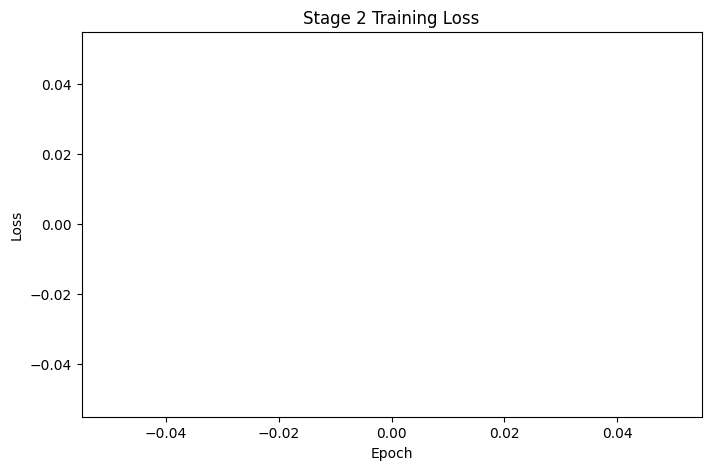

In [61]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(loss_list) + 1), loss_list)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Stage 2 Training Loss")
plt.show()

# Testing Data Evaluation

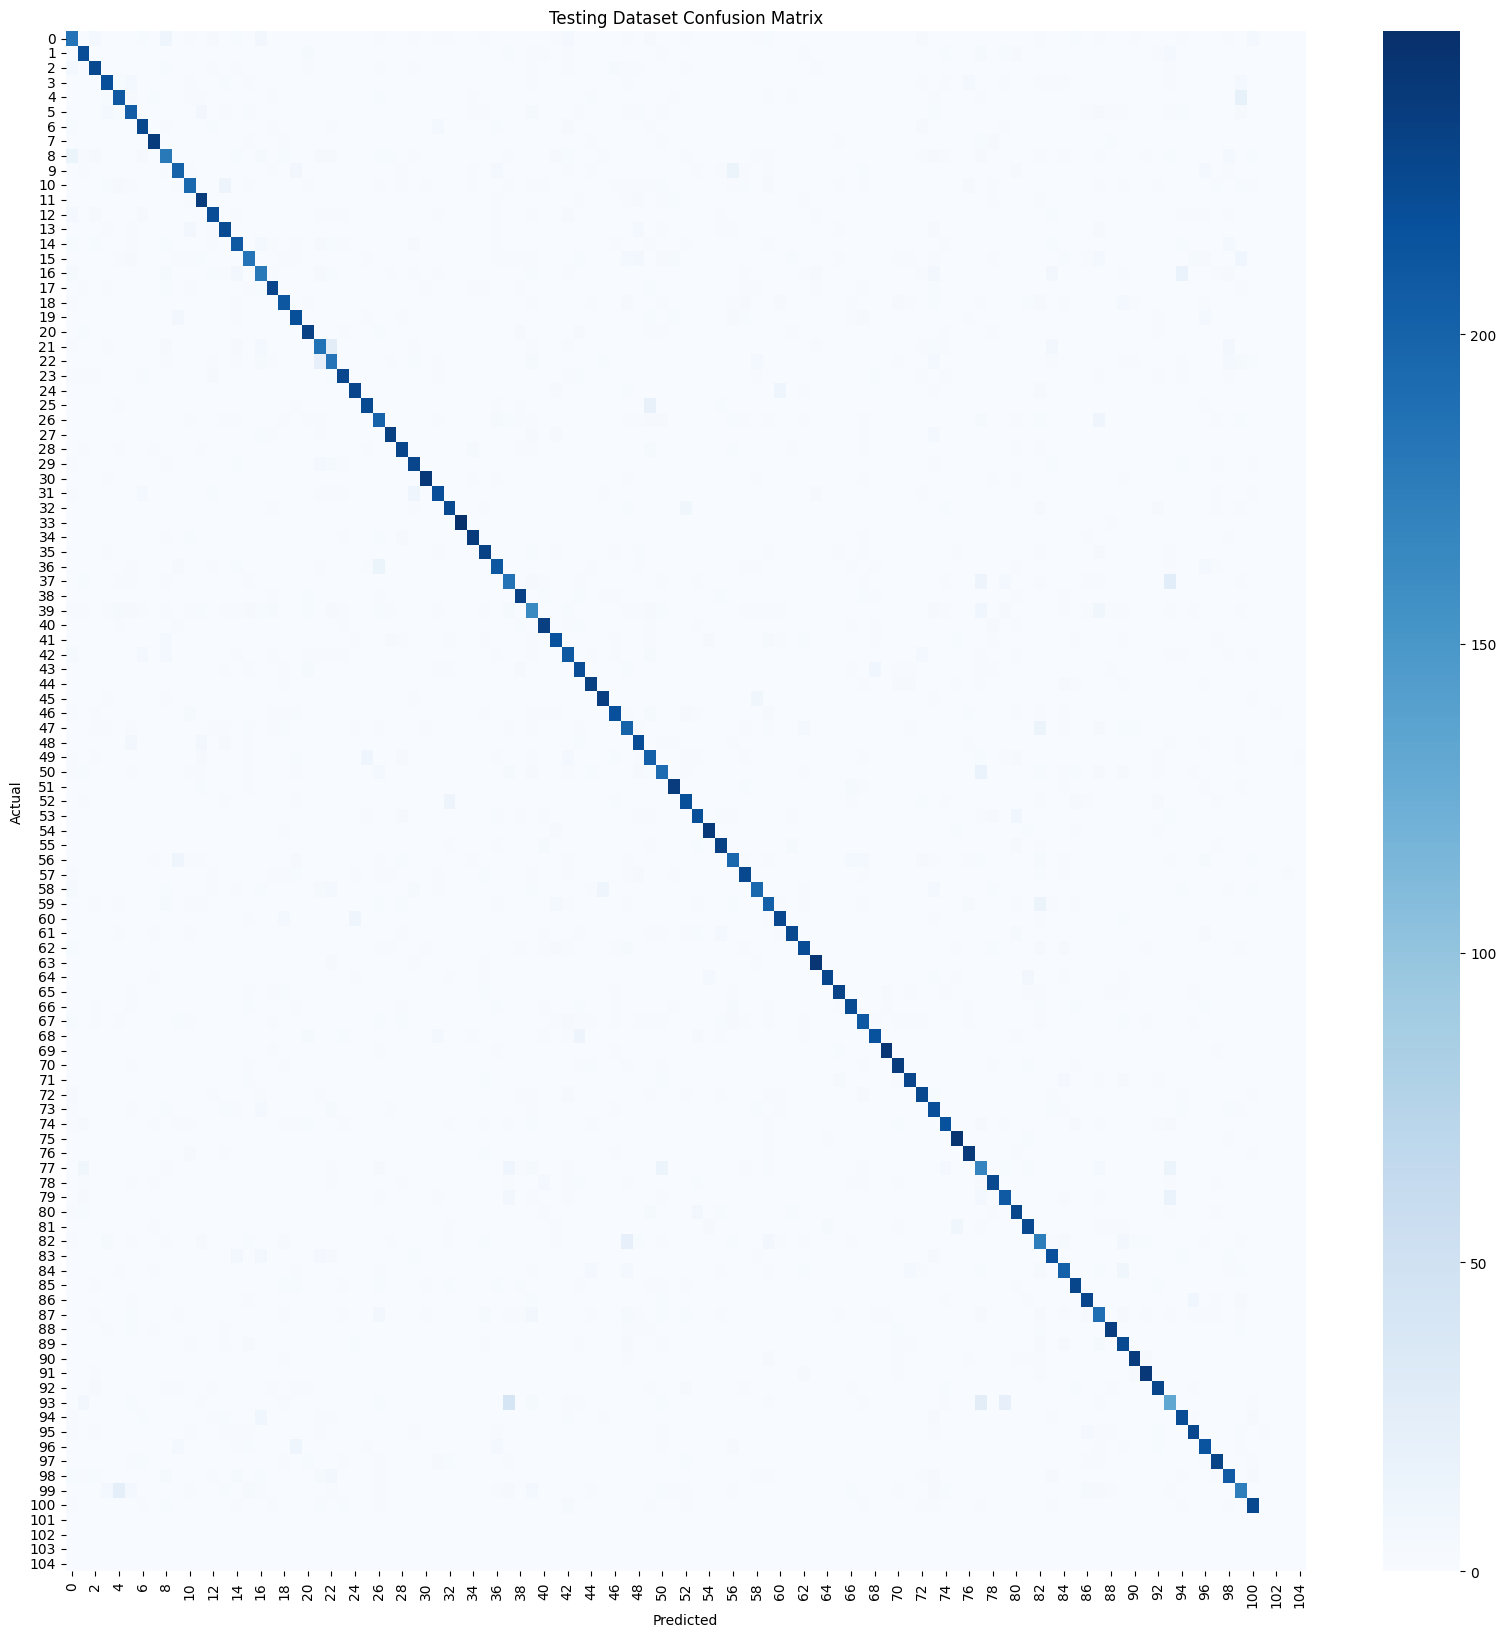

Testing Accuracy: 0.8684752475247525


In [70]:
test_accuracy, cm = evaluation(model, testing_Dataloader, device, return_confusion_matrix=True)

plt.figure(figsize=(20, 20))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Testing Dataset Confusion Matrix')
plt.show()

print(f"Testing Accuracy: {test_accuracy}")


# Image Prediction

In [71]:
def predict(model, image_path, index_to_class, device, top_k=3):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt")
    pixel_values = inputs["pixel_values"].to(device)

    with torch.no_grad():
        output = model(pixel_values=pixel_values)
        probs = F.softmax(output.logits, dim=1)
        top_probs, top_indices = torch.topk(probs, top_k)

    return [
        (index_to_class[idx], prob)
        for idx, prob in zip(top_indices[0].tolist(), top_probs[0].tolist())
    ]

In [74]:
results = predict(model, test_images_paths[0], index_to_class, device)

for class_name, confidence in results:
    print(f"{class_name}: {confidence:.2%}")


samosa: 73.54%
gyoza: 23.13%
grilled_cheese_sandwich: 1.46%


# Visualization

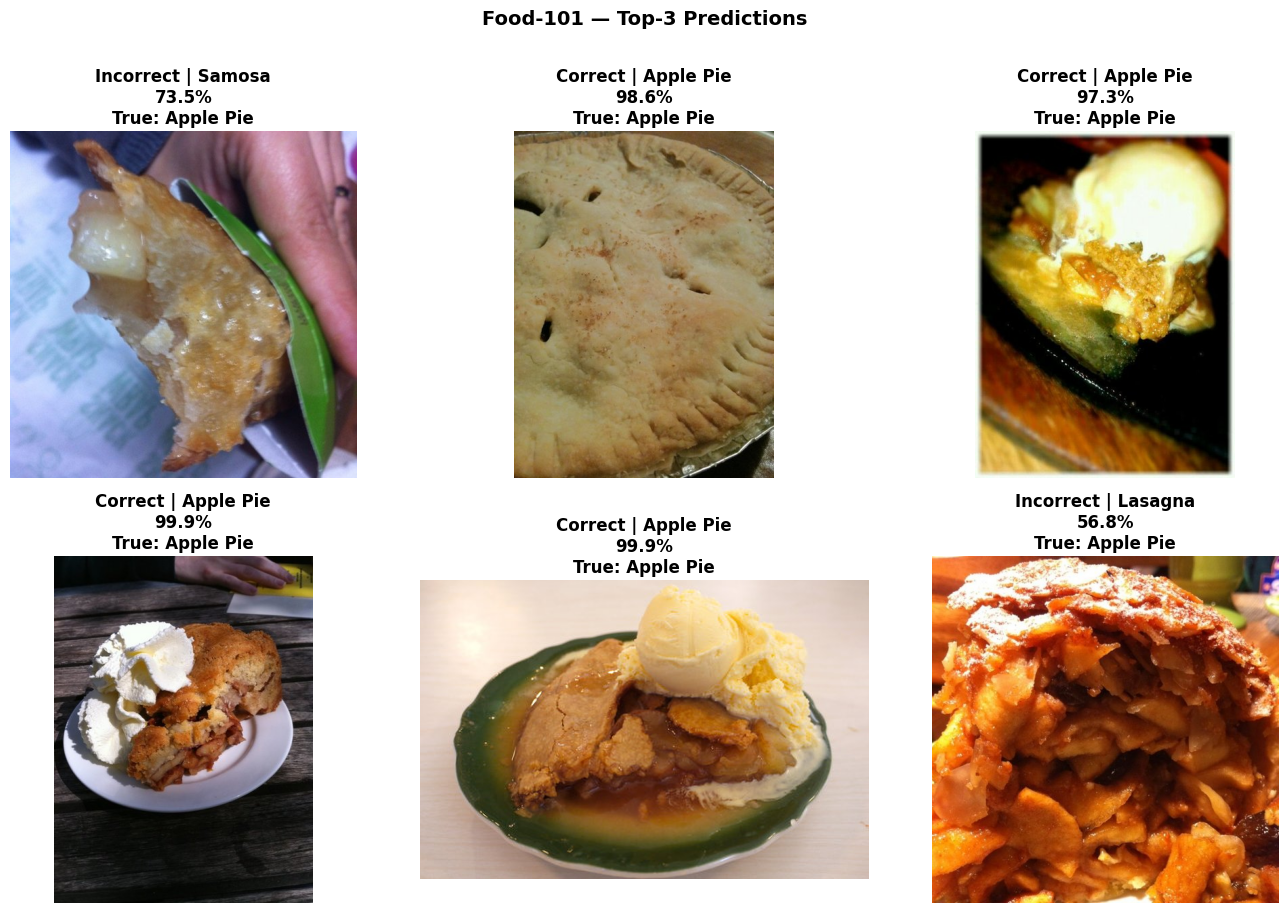

In [76]:
def show_predictions(image_paths, model, index_to_class, device, n=6):
    """Display n test images with their top-3 predictions."""
    fig, axes = plt.subplots(2, 3, figsize=(14, 9))
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        image_path = image_paths[i]
        true_label = os.path.basename(os.path.dirname(image_path))

        display_img = Image.open(image_path).convert("RGB")
        results = predict(model, image_path, index_to_class, device)

        top_name, top_conf = results[0]
        correct = "Correct" if top_name == true_label else "Incorrect"
        label = f"{correct} | {top_name.replace('_', ' ').title()}\n{top_conf:.1%}\nTrue: {true_label.replace('_', ' ').title()}"

        runners = "\n".join(
            f"  {name.replace('_', ' ').title()}: {conf:.1%}"
            for name, conf in results[1:]
        )

        ax.imshow(display_img)
        ax.axis('off')
        ax.set_title(label, fontsize=12, fontweight="bold", pad=6)
        ax.set_xlabel(runners, fontsize=9, labelpad=4)

    plt.suptitle("Food-101 — Top-3 Predictions", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


show_predictions(test_images_paths, model, index_to_class, device)
